In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
sys.path.append('/content/drive/MyDrive/optimized_kan')

In [3]:
from kan import *
import torch
from torch.quantization import QuantStub, DeQuantStub
import matplotlib.pyplot as plt
import numpy as np
import wandb

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).

cuda


Create dataset

In [4]:
from kan.utils import create_dataset
from torch.distributions.normal import Normal

eps = 1e-6

# create dataset f(x,y) = exp(sin(pi*x)+y^2)
f = lambda x: (
    x[:, [0]].clamp(min=eps) * Normal(0, 1).cdf(
        (torch.log((x[:, [0]] / x[:, [1]].clamp(min=eps)).clamp(min=eps)) +
         (x[:, [3]] + 0.5 * x[:, [4]]**2) * x[:, [2]]) /
        (x[:, [4]].clamp(min=eps) * torch.sqrt(x[:, [2]].clamp(min=eps)) + eps)
    ) -
    x[:, [1]].clamp(min=eps) * torch.exp(-x[:, [3]] * x[:, [2]]) *
    Normal(0, 1).cdf(
        (torch.log((x[:, [0]] / x[:, [1]].clamp(min=eps)).clamp(min=eps)) +
         (x[:, [3]] - 0.5 * x[:, [4]]**2) * x[:, [2]]) /
        (x[:, [4]].clamp(min=eps) * torch.sqrt(x[:, [2]].clamp(min=eps)) + eps)
    )
)

In [12]:
# WandB Specific
entity = "hpml_project_spring25"
project = "Profiling_Speedups"

# Dataset Specific
n_var = 5
train_num = 10_000
test_num = 10_000

#Model Specific
seed = 42
grid_size = 16
grid_range = [-1, 1]
spline_order = 3
hidden_dim = [11, 11]
out_dim = 1

# Training Specfic
batch_size = -1
training_steps = 1000
opt = "Adam"
lr = 0.001



dataset = create_dataset(f, n_var=n_var, train_num=train_num, test_num=test_num, device=device)
dataset['train_input'].shape, dataset['train_label'].shape


(torch.Size([10000, 5]), torch.Size([10000, 1]))

Train KAN with sparsity regularization

In [31]:
# train the kan_model
# Initialize W&B project
run = wandb.init(
    entity=entity,
    project=project,
    name="Vanilla KAN",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "spline_order":spline_order,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

kan_model = KAN(width=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid=wandb.config.grid_size,
                grid_range=wandb.config.grid_range,
                k=wandb.config.spline_order,
                seed=wandb.config.seed,
                device=device)
kan_model(dataset['train_input'][[0]])

kan_metrics = kan_model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

run.finish()

/content/drive/MyDrive/optimized_kan/kan/MultKAN.py:819: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  self.subnode_actscale.append(torch.std(x, dim=0).detach())
/content/drive/MyDrive/optimized_kan/kan/MultKAN.py:829: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  input_range = torch.std(preacts, dim=0) + 0.1
/content/drive/MyDrive/optimized_kan/kan/MultKAN.py:830: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  output_range_spline = torch.std(postacts_numer

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 4.65e-02 | test_loss: 7.91e-02 | reg: 1.00e+01 |: 100%|█| 1000/1000 [01:52<00:00,  8.8


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     151.395ms        47.59%     151.395ms      50.465ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▁▂▂▂▂▂▂▂▁▁▁▂▃▂▁▁▁▂▃▄▁▁▁▁▁█▁▁▁▁▂▂▃▁▁▁▁▁▁▂
reg,██▇▇▇▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▂▂▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,█▆▆▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▆▅▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),1331.59858
cuda_time_total (ms),318.11601


In [32]:
run = wandb.init(
    entity=entity,
    project=project,
    name="Vanilla KAN Compiled",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "spline_order":spline_order,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})


compiled_kan_model = KAN(width=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid=wandb.config.grid_size,
                grid_range=wandb.config.grid_range,
                k=wandb.config.spline_order,
                seed=wandb.config.seed,
                device=device).speed(compile=True)

compiled_kan_model(dataset['train_input'][[0]])

compiled_kan_metrics = compiled_kan_model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)
run.finish()


checkpoint directory created: ./model
saving model version 0.0
setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 1.60e-02 | test_loss: 8.03e-02 | reg: 0.00e+00 |: 100%|█| 1000/1000 [01:36<00:00, 10.3


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     114.930ms        39.07%     114.930ms      38.310ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▄▅▂▃▃▃▄▄▆█▅█▄▅▄▅▃▃▄▂▃▃▃▃▅▃▃▃▁▃▂▆▄▂▃▅▃▂▃▄
reg,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train_loss,█▇▆▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),1159.6727
cuda_time_total (ms),294.1291


In [34]:
run = wandb.init(
    entity=entity,
    project=project,
    name="Vanilla KAN Compiled w/ Options",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "spline_order":spline_order,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

compiled_opt_kan_model = KAN(width=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid=wandb.config.grid_size,
                grid_range=wandb.config.grid_range,
                k=wandb.config.spline_order,
                seed=wandb.config.seed,
                device=device).speed(compile=True, dynamic=False, fullgraph=True, options={"trace.enabled":True, "trace.graph_diagram":False, "triton.cudagraphs":True})

compiled_opt_kan_model(dataset['train_input'][[0]])

compiled_opt_kan_metrics = compiled_opt_kan_model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

run.finish()

checkpoint directory created: ./model
saving model version 0.0


/usr/local/lib/python3.11/dist-packages/torch/utils/_config_module.py:342: UserWarning: Skipping serialization of skipfiles_inline_module_allowlist value {}
  warnings.warn(
skipping cudagraphs due to skipping cudagraphs due to cpu device (primals_1). Found from : 
   File "/content/drive/MyDrive/optimized_kan/kan/MultKAN.py", line 785, in forward
    x = x[:,self.input_id.long()]

W0511 19:58:40.185000 164 torch/_inductor/debug.py:435] [1/2] model__3_forward_10 debug trace: /content/torch_compile_debug/run_2025_05_11_19_18_07_351304-pid_164/torchinductor/model__3_forward_10.1


setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 1.60e-02 | test_loss: 8.03e-02 | reg: 0.00e+00 |: 100%|█| 1000/1000 [01:36<00:00, 10.3


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     115.328ms        39.21%     115.328ms      38.443ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▃▂▄▃▃▆▃▅▄▇▅▂▃▂▁▁▁▁██▅▃▃▃▂▄▃▁▁▃▄▄▅▄▃▂▃▃▃▃
reg,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇█
train_loss,██▇▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,██▄▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),1150.16502
cuda_time_total (ms),294.16269


In [35]:
run = wandb.init(
    entity=entity,
    project=project,
    name="Mixed Precision KAN",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "spline_order":spline_order,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

mpkan_model = MPKAN(width=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid=wandb.config.grid_size,
                grid_range=wandb.config.grid_range,
                k=wandb.config.spline_order,
                seed=wandb.config.seed,
                device=device)

mpkan_model(dataset['train_input'][[0]])

mpkan_metrics = mpkan_model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

run.finish()

/content/drive/MyDrive/optimized_kan/kan/MultKAN.py:819: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  self.subnode_actscale.append(torch.std(x, dim=0).detach())
/content/drive/MyDrive/optimized_kan/kan/MultKAN.py:829: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  input_range = torch.std(preacts, dim=0) + 0.1
/content/drive/MyDrive/optimized_kan/kan/MultKAN.py:830: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  output_range_spline = torch.std(postacts_numer

checkpoint directory created: ./model
saving model version 0.0


description:   0%|                                                         | 0/1000 [00:00<?, ?it/s]/content/drive/MyDrive/optimized_kan/kan/MixedKAN.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(opt == "Adam"))
/content/drive/MyDrive/optimized_kan/kan/MixedKAN.py:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
| train_loss: 5.38e-02 | test_loss: 7.63e-02 | reg: 1.01e+01 |: 100%|█| 1000/1000 [01:55<00:00,  8.6


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     354.893ms       132.45%     354.893ms     118.298ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▁█▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
reg,███▇▆▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇█
train_loss,█▇▇▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▆▅▄▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),1158.89464
cuda_time_total (ms),267.94364


In [36]:
# train the kan_model
# Initialize W&B project
run = wandb.init(
    entity=entity,
    project=project,
    name="Mixed Precision KAN Compiled",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "spline_order":spline_order,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

compiled_mpkan_model = MPKAN(width=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid=wandb.config.grid_size,
                grid_range=wandb.config.grid_range,
                k=wandb.config.spline_order,
                seed=wandb.config.seed,
                device=device).speed(compile=True)

compiled_mpkan_model(dataset['train_input'][[0]])

compiled_mpkan_metrics = compiled_mpkan_model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

run.finish()

checkpoint directory created: ./model
saving model version 0.0
setting lamb=0. If you want to set lamb > 0, set self.save_act=True


description:   0%|                                                         | 0/1000 [00:00<?, ?it/s]/content/drive/MyDrive/optimized_kan/kan/MixedKAN.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(opt == "Adam"))
/content/drive/MyDrive/optimized_kan/kan/MixedKAN.py:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
| train_loss: 1.60e-02 | test_loss: 8.04e-02 | reg: 0.00e+00 |: 100%|█| 1000/1000 [01:37<00:00, 10.2


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     287.043ms       116.57%     287.043ms      95.681ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▅▂▄▄▃▂▅▇▆▃▅▅█▅▅▅▄▂▃▄█▇▄▃▁▄▁▂▅▅▄▆▆▅▁▂▂▂▃▂
reg,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇██
train_loss,█▇▅▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▆▄▄▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),983.84515
cuda_time_total (ms),246.24743


In [37]:
run = wandb.init(
    entity=entity,
    project=project,
    name="Mixed Precision KAN Compiled w/ Options",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "spline_order":spline_order,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

compiled_opt_mpkan_model = MPKAN(width=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid=wandb.config.grid_size,
                grid_range=wandb.config.grid_range,
                k=wandb.config.spline_order,
                seed=wandb.config.seed,
                device=device).speed(compile=True, dynamic=False, fullgraph=True, options={"trace.enabled":True, "trace.graph_diagram":False, "triton.cudagraphs":True})

compiled_opt_mpkan_model(dataset['train_input'][[0]])

compiled_opt_mpkan_metrics = compiled_opt_mpkan_model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

run.finish()

checkpoint directory created: ./model
saving model version 0.0


skipping cudagraphs due to skipping cudagraphs due to cpu device (primals_1). Found from : 
   File "/content/drive/MyDrive/optimized_kan/kan/MultKAN.py", line 785, in forward
    x = x[:,self.input_id.long()]

W0511 20:05:06.392000 164 torch/_inductor/debug.py:435] [1/4] model__5_forward_16 debug trace: /content/torch_compile_debug/run_2025_05_11_19_18_07_351304-pid_164/torchinductor/model__5_forward_16.2


setting lamb=0. If you want to set lamb > 0, set self.save_act=True


description:   0%|                                                         | 0/1000 [00:00<?, ?it/s]/content/drive/MyDrive/optimized_kan/kan/MixedKAN.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(opt == "Adam"))
/content/drive/MyDrive/optimized_kan/kan/MixedKAN.py:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
| train_loss: 1.61e-02 | test_loss: 8.03e-02 | reg: 0.00e+00 |: 100%|█| 1000/1000 [01:36<00:00, 10.3


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     289.973ms       117.27%     289.973ms      96.658ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
reg,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇█
train_loss,█▅▅▅▅▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▅▅▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),981.78771
cuda_time_total (ms),247.2647


In [38]:
run = wandb.init(
    entity=entity,
    project=project,
    name="FastKAN",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = FastKAN(layers_hidden=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid_min=wandb.config.grid_range[0],
                grid_max=wandb.config.grid_range[1],
                num_grids=wandb.config.grid_size).to(device)

model(dataset['train_input'][[0]])

fastkan_metrics = model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)


run.finish()

| train_loss: 1.58e-01 | test_loss: 7.04e-02 | : 100%|██████████| 1000/1000 [00:20<00:00, 49.91it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      67.230ms        73.34%      67.230ms      22.410ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▂▂▁▁▂▂▃▃▃▂█▆▇▃▁▂▂▁▁▃▂▃▂▂▂▁▂▂▆▃▃▂▃▆▃▂▃▅▃▄
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▂▂▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇██
train_loss,██▆▆▆▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_loss,█▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),431.27259
cuda_time_total (ms),91.66572
exec_time,0.0175


In [39]:
run = wandb.init(
    entity=entity,
    project=project,
    name="FastKAN Compiled",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = torch.compile(FastKAN(layers_hidden=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                              grid_min=wandb.config.grid_range[0],
                              grid_max=wandb.config.grid_range[1],
                              num_grids=wandb.config.grid_size
                              ).to(device),)

model(dataset['train_input'][[0]])

compiled_fastkan_metrics = model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

run.finish()

| train_loss: 1.48e-01 | test_loss: 5.94e-02 | : 100%|██████████| 1000/1000 [00:20<00:00, 49.55it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      55.207ms        87.35%      55.207ms      18.402ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▂▂▂▂▁▁▁▁▁▂▃▂▁▂▆▅▂▃▅▃▃▃▂▃▁▂▃▂▂▂▄▁▃▃█▂▁▂▁▃
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▁▂▂▂▂▂▂▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇████
train_loss,██▇▇▅▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▇▆▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),315.14389
cuda_time_total (ms),63.20442
exec_time,0.01791


In [40]:
run = wandb.init(
    entity=entity,
    project=project,
    name="FastKAN Compiled w/ Options",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = torch.compile(FastKAN(layers_hidden=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                              grid_min=wandb.config.grid_range[0],
                              grid_max=wandb.config.grid_range[1],
                              num_grids=wandb.config.grid_size).to(device),
                      dynamic=False,
                      fullgraph=True,
                      options={"trace.enabled":True, "trace.graph_diagram":False, "triton.cudagraphs":True})

model(dataset['train_input'][[0]])

compiled_opt_fastkan_metrics = model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

run.finish()

/usr/local/lib/python3.11/dist-packages/torch/utils/_config_module.py:342: UserWarning: Skipping serialization of skipfiles_inline_module_allowlist value {}
  warnings.warn(
W0511 20:07:36.838000 164 torch/_inductor/debug.py:435] [0/3] model__7_forward_22 debug trace: /content/torch_compile_debug/run_2025_05_11_19_18_07_351304-pid_164/torchinductor/model__7_forward_22.3
| train_loss: 1.61e-01 | test_loss: 7.00e-02 | : 100%|██████████| 1000/1000 [00:20<00:00, 47.80it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      74.469ms        88.09%      74.469ms      24.823ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▂▂▂▁▂▂▁▃▂▂▁▂▂▂▃▂▂▃▂▃▂▂▂▂▂▃█▆▇▄▂▃▆▁▁▁▂▁▂▂
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▂▂▂▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
train_loss,█▇▇▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▆▄▄▄▄▄▄▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),438.90256
cuda_time_total (ms),84.53344
exec_time,0.0177


In [41]:
run = wandb.init(
    entity=entity,
    project=project,
    name="FastMPKAN",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = FastMPKAN(layers_hidden=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid_min=wandb.config.grid_range[0],
                grid_max=wandb.config.grid_range[1],
                num_grids=wandb.config.grid_size).to(device)

model(dataset['train_input'][[0]])

compiled_opt_fastmpkan_metrics = model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)


run.finish()

/content/drive/MyDrive/optimized_kan/kan/FastMixedKAN.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
description:   0%|                                                         | 0/1000 [00:00<?, ?it/s]/content/drive/MyDrive/optimized_kan/kan/FastMixedKAN.py:75: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/content/drive/MyDrive/optimized_kan/kan/FastMixedKAN.py:108: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(opt == "Adam")):
| train_loss: 1.48e-01 | test_loss: 6.40e-02 | : 100%|██████████| 1000/1000 [00:19<00:00, 51.83it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     103.314ms       129.57%     103.314ms      34.438ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▂▂▂▁▅▄▂▇▄▂▃▄▂▂▁▁▁▂▁▃▂▂█▁▂▁▃▁▁▂▂▂▂▁▂▂▁▄▃▁
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇██
train_loss,█▆▆▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▅▅▅▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),335.20223
cuda_time_total (ms),79.7339
exec_time,0.01625


In [42]:
run = wandb.init(
    entity=entity,
    project=project,
    name="FastMPKAN Compiled",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = torch.compile(FastMPKAN(layers_hidden=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid_min=wandb.config.grid_range[0],
                grid_max=wandb.config.grid_range[1],
                num_grids=wandb.config.grid_size).to(device))
model(dataset['train_input'][[0]])
fastmpkan_metrics = model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)


run.finish()

/content/drive/MyDrive/optimized_kan/kan/FastMixedKAN.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
description:   0%|                                                         | 0/1000 [00:00<?, ?it/s]/content/drive/MyDrive/optimized_kan/kan/FastMixedKAN.py:75: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/content/drive/MyDrive/optimized_kan/kan/FastMixedKAN.py:108: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(opt == "Adam")):
| train_loss: 1.47e-01 | test_loss: 6.40e-02 | : 100%|██████████| 1000/1000 [00:19<00:00, 52.22it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     102.093ms       123.19%     102.093ms      34.031ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▂▂▂▂▁▂▃▂▃▃▁▂▁▄▃▂▄▃▄▅▄▂▅▇█▁█▅▂▁▁▅▄▃▃▃▄▃▃▂
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▁▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▇▇▇▇▇▇████
train_loss,█▆▆▆▆▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▆▆▆▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),337.26645
cuda_time_total (ms),82.87489
exec_time,0.016


In [43]:
run = wandb.init(
    entity=entity,
    project=project,
    name="FastMPKAN Compiled w/ Options",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = torch.compile(FastMPKAN(layers_hidden=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                              grid_min=wandb.config.grid_range[0],
                              grid_max=wandb.config.grid_range[1],
                              num_grids=wandb.config.grid_size).to(device),
                      dynamic=False,
                      fullgraph=True,
                      options={"trace.enabled":True, "trace.graph_diagram":False, "triton.cudagraphs":True})
model(dataset['train_input'][[0]])
compiled_opt_fastmpkan_metrics = model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

run.finish()

W0511 20:08:45.003000 164 torch/_inductor/debug.py:435] [0/5] model__9_forward_28 debug trace: /content/torch_compile_debug/run_2025_05_11_19_18_07_351304-pid_164/torchinductor/model__9_forward_28.4
/content/drive/MyDrive/optimized_kan/kan/FastMixedKAN.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
description:   0%|                                                         | 0/1000 [00:00<?, ?it/s]/content/drive/MyDrive/optimized_kan/kan/FastMixedKAN.py:75: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/content/drive/MyDrive/optimized_kan/kan/FastMixedKAN.py:108: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(opt == "Adam")):
| train_loss: 

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     104.310ms       125.88%     104.310ms      34.770ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▂█▅▃▁▅▂▃▃▄▆▁▁▂▁▂▁▂▃▁▁▃▃▂▂▃▁▂▂▇▅▂▃▂▄▂▃▃▄▄
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇▇████
train_loss,█▆▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,██▇▇▆▄▄▄▄▄▄▄▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),345.12955
cuda_time_total (ms),82.86184
exec_time,0.01566


In [13]:
# Initialize quantized model
try:
    run.finish()
except:
    pass
run = wandb.init(
    entity=entity,
    project=project,
    name="QuantFastKAN",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "spline_order":spline_order,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = QuantFastKAN(layers_hidden=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                              grid_min=wandb.config.grid_range[0],
                              grid_max=wandb.config.grid_range[1],
                              num_grids=wandb.config.grid_size).to(device)

for module in model.modules():
    if isinstance(module, (QuantSplineLinear, QuantRadialBasisFunction)):
        module.qconfig = torch.ao.quantization.get_default_qat_qconfig('x86')
qat_model = torch.ao.quantization.prepare_qat(model)

qat_model.fit(dataset,
        opt=wandb.config.optimizer,
        batch=wandb.config.batch_size,
        steps=wandb.config.training_steps,
        lr=wandb.config.lr,
        lamb=0.001,
       profile=True)


run.finish()

| train_loss: 1.47e-01 | test_loss: 6.64e-02 | : 100%|██████████| 1000/1000 [00:11<00:00, 85.58it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      42.773ms       264.82%      42.773ms      14.258ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▆▄██▅▅▆▄▅▃▃▄▃▅▇█▄▄▂▂▁▂▂▂▁▂▁▅▁▂▁▃▃▁▂▄▁▁▁▅
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇██
train_loss,█▅▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▅▄▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),144.56049
cuda_time_total (ms),16.1517
exec_time,0.00856


In [14]:
# Initialize quantized model
try:
    run.finish()
except:
    pass
run = wandb.init(
    entity=entity,
    project=project,
    name="QuantFastKAN Compiled",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "spline_order":spline_order,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = QuantFastKAN(layers_hidden=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                              grid_min=wandb.config.grid_range[0],
                              grid_max=wandb.config.grid_range[1],
                              num_grids=wandb.config.grid_size).to(device)

for module in model.modules():
    if isinstance(module, (QuantSplineLinear, QuantRadialBasisFunction)):
        module.qconfig = torch.ao.quantization.get_default_qat_qconfig('x86')

qat_model = torch.ao.quantization.prepare_qat(model)

qat_model = torch.compile(qat_model)

qat_model.fit(dataset,
        opt=wandb.config.optimizer,
        batch=wandb.config.batch_size,
        steps=wandb.config.training_steps,
        lr=wandb.config.lr,
        lamb=0.001,
       profile=True)


run.finish()

| train_loss: 1.45e-01 | test_loss: 6.25e-02 | : 100%|██████████| 1000/1000 [00:11<00:00, 87.39it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      35.040ms       216.83%      35.040ms      11.680ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▄▄▄▃▃▃▆▃▆█▆▇▁▂▂▁▂▃▂▁▂▂▂▂▃▁▂▁▂▂▁▂▁▂▂▁▂▁▂▄
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
train_loss,█▆▅▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,██▇▅▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),127.29254
cuda_time_total (ms),16.16001
exec_time,0.00866


In [15]:
# Initialize quantized model
try:
    run.finish()
except:
    pass
run = wandb.init(
    entity=entity,
    project=project,
    name="QuantFastKAN Compiled w/ Options",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "spline_order":spline_order,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = QuantFastKAN(layers_hidden=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                              grid_min=wandb.config.grid_range[0],
                              grid_max=wandb.config.grid_range[1],
                              num_grids=wandb.config.grid_size).to(device)

for module in model.modules():
    if isinstance(module, (QuantSplineLinear, QuantRadialBasisFunction)):
        module.qconfig = torch.ao.quantization.get_default_qat_qconfig('x86')

qat_model = torch.ao.quantization.prepare_qat(model)

qat_model = torch.compile(qat_model, dynamic=False,
                      fullgraph=True,
                      options={"trace.enabled":True, "trace.graph_diagram":False, "triton.cudagraphs":True})

qat_model.fit(dataset,
        opt=wandb.config.optimizer,
        batch=wandb.config.batch_size,
        steps=wandb.config.training_steps,
        lr=wandb.config.lr,
        lamb=0.001,
       profile=True)


run.finish()

| train_loss: 1.44e-01 | test_loss: 6.38e-02 | : 100%|██████████| 1000/1000 [00:11<00:00, 87.18it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      32.541ms       201.50%      32.541ms      10.847ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▅▄▅▄▆▃▃▃▄▅▆▅▆▅▅▂▂▂▁▂▁▁▁▁▁▁▁▁▁▂▂▄▂▁▁▂█▁▃▃
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▁▁▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
train_loss,█▆▅▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▅▅▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),120.92894
cuda_time_total (ms),16.14975
exec_time,0.00901


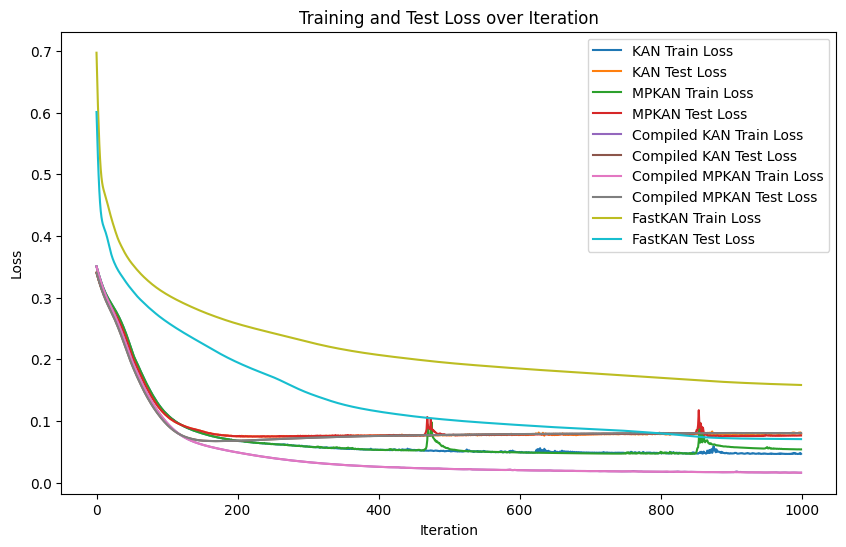

In [44]:
plt.figure(figsize=(10, 6))

plt.plot(np.array(kan_metrics['train_loss']), label='KAN Train Loss')
plt.plot(np.array(kan_metrics['test_loss']), label='KAN Test Loss')
plt.plot(np.array(mpkan_metrics['train_loss']), label='MPKAN Train Loss')
plt.plot(np.array(mpkan_metrics['test_loss']), label='MPKAN Test Loss')
plt.plot(np.array(compiled_kan_metrics['train_loss']), label='Compiled KAN Train Loss')
plt.plot(np.array(compiled_kan_metrics['test_loss']), label='Compiled KAN Test Loss')
plt.plot(np.array(compiled_mpkan_metrics['train_loss']), label='Compiled MPKAN Train Loss')
plt.plot(np.array(compiled_mpkan_metrics['test_loss']), label='Compiled MPKAN Test Loss')

plt.plot(np.array(fastkan_metrics['train_loss']), label='FastKAN Train Loss')
plt.plot(np.array(fastkan_metrics['test_loss']), label='FastKAN Test Loss')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Iteration')
plt.legend()  # No arguments needed; uses the labels above
plt.show()
